# Week 05 · Minimax, α-β y el torneo de Connect-4
### Salazar · Ochoa · Chano
**CMP-4004 — Inteligencia Artificial**

Nuestra pregunta: **¿qué nos garantiza una búsqueda adversarial con reloj, y qué hace un modelo de lenguaje cuando juega el mismo juego sin buscar?**

Presentamos cuatro resultados:
1. un agente `choose_move` con α-β y profundización iterativa que cumple el reloj de 500 ms;
2. la comprobación de las dos garantías de la semana, que son el valor exacto de α-β y el efecto horizonte;
3. un mini torneo local con las reglas del plan;
4. el retador LLM con el prompt exacto de la consigna, medido sobre un banco táctico y en partidas.

**Recorrido:** consigna → conceptos → agente → pruebas → garantías → torneo → retador LLM → scorecard → conclusiones.

## 1. Preparación y archivos que presentamos

Abrimos este notebook desde la carpeta de entrega y ejecutamos las celdas en orden. Las salidas guardadas corresponden a una ejecución completa desde un kernel limpio.

| Archivo | Papel en el trabajo |
|---|---|
| `connect4.py` | Motor dado por el curso: tablero, `minimax`, `alphabeta`, órdenes estáticos y `play`. **Sin cambios** |
| `starter.py` | Nuestro agente: `order_moves`, `search_profile` y `choose_move` |
| `test_alphabeta.py` | Los 7 tests de la consigna. **Sin cambios** |
| `test_group.py` | 13 comprobaciones adicionales del grupo |
| `tactics.py`, `tactical_bank.json` | Banco táctico de 80 posiciones verificadas |
| `tournament.py` | Mini torneo con la regla de 500 ms por jugada |
| `experiments.py`, `resultados/` | Mediciones clásicas guardadas con huellas |
| `llm_challenger.py`, `resultados_llm/`, `.llm_cache/` | Retador LLM: resultados, registro de cada llamada y caché |
| `aicourse/` | Harness del curso (semana 0) para llamar al LLM |

In [1]:
from pathlib import Path
import sys, json, inspect, subprocess, html, csv, statistics
from collections import Counter, defaultdict
from IPython.display import display, HTML, Markdown
import matplotlib.pyplot as plt

ROOT = Path.cwd()
assert (ROOT / 'starter.py').exists(), 'Abrir el notebook desde la carpeta de entrega.'
from connect4 import Connect4, minimax, alphabeta, play, MAX, MIN, CENTER_FIRST
import starter as s, tactics, tournament, experiments as ex, llm_challenger as llm

def tabla(headers, rows):
    def fmt(v):
        return f'{v:,.2f}' if isinstance(v, float) else str(v)
    head = ''.join(f'<th>{html.escape(str(h))}</th>' for h in headers)
    body = ''.join('<tr>' + ''.join(f'<td>{html.escape(fmt(v))}</td>' for v in row) + '</tr>' for row in rows)
    display(HTML('<table><thead><tr>' + head + '</tr></thead><tbody>' + body + '</tbody></table>'))

def pct(a, b):
    return f'{a}/{b} ({100 * a / b:.0f} %)'

print('Equipo: Salazar, Ochoa y Chano')
print('Python:', sys.version.split()[0])
print('Implementación importada:', Path(s.__file__).name)

Equipo: Salazar, Ochoa y Chano
Python: 3.12.10
Implementación importada: starter.py


## 2. De la week 04 a la week 05: qué pide el Studio 5

En la semana 4 buscábamos caminos con A* en un ambiente donde **solo nosotros actuábamos**. Ahora hay un **adversario**, así que ya no basta con encontrar una secuencia de jugadas: necesitamos una jugada que funcione **frente a cualquier respuesta** del rival.

La consigna (`referencias/studios/week-05/README.md`) es distinta a las anteriores, porque la sesión 5B **es el torneo**. Antes de clase entregamos un agente con esta interfaz:

```python
def choose_move(board, time_budget_ms) -> int: ...
```

Reglas del plan: **500 ms por jugada**, sin procesos externos ni red, y sin un libro de aperturas de más de 20 posiciones. Una jugada que se pasa del tiempo pierde la partida.

Lo que pedía la consigna y dónde está en este notebook:

| Requisito | Dónde lo mostramos |
|---|---|
| Completar `order_moves` y `choose_move` (profundización iterativa sobre el `alphabeta` dado) | Secciones 4 y 5 |
| Pasar los 7 tests de `test_alphabeta.py` | Sección 6 |
| Entender las dos garantías: α-β = minimax con menos nodos, y el efecto horizonte | Secciones 7 a 9 |
| Retador LLM con el prompt del plan: legalidad, victorias perdidas, bloqueos, latencia y Failure Atlas | Secciones 12 a 16 |

**No confundimos actividades:** el Duel 1 (`homework/hw1`, asignado en la semana 5) es otra entrega y no forma parte de este trabajo. Tampoco tomamos el Studio 4 como tarea nuestra: fue resuelto por el profesor, y aquí solo lo usamos como referencia técnica (el prompt exacto y el verificador que no le cree al modelo).

## 3. Conceptos que necesitamos

| Concepto | Qué significa en Connect-4 | Cómo lo usamos |
|---|---|---|
| **Minimax** | MAX elige el máximo y MIN el mínimo; el valor supone que el rival juega perfecto | Es la definición del valor del juego, y la referencia contra la que comparamos α-β |
| **α-β** | `alpha` = lo que MAX ya tiene asegurado y `beta` = lo que MIN ya tiene asegurado. Si `alpha >= beta`, el resto de la rama no puede cambiar la decisión | La función `alphabeta` dada, a la que solo le entregamos el orden |
| **Orden de jugadas** | α-β poda más si examina primero las mejores jugadas; en el caso ideal son O(b^(m/2)) nodos | Centro primero, y la mejor jugada de la iteración anterior al inicio |
| **Profundización iterativa** | Buscar a profundidad 1, 2, 3… y quedarse con la última completa | Es lo que convierte a α-β en un agente que respeta el reloj |
| **Función de evaluación** | `evaluate()` puntúa las ventanas de 4 casillas y la columna central; ±10 000 si ya hay ganador | Viene dada; no la modificamos |
| **Efecto horizonte** | Un agente limitado no ve una amenaza que se resuelve más allá de su profundidad | La sección 9 lo muestra |

Una advertencia que repetimos a lo largo del trabajo: la garantía de α-β es de **exactitud respecto a minimax a la misma profundidad**. No dice que el agente juegue perfecto. Eso solo ocurriría si buscara hasta el final del juego.

In [2]:
b = tactics.board_from_moves([3, 3, 2, 4])     # empieza MIN; quedan 4 fichas y mueve MAX
print(b)
print('Jugadas legales:', b.legal_moves())
print('evaluate() desde MAX:', b.evaluate())

|. . . . . . .|
|. . . . . . .|
|. . . . . . .|
|. . . . . . .|
|. . . X . . .|
|. . O O X . .|
 0 1 2 3 4 5 6
Jugadas legales: [0, 1, 2, 3, 4, 5, 6]
evaluate() desde MAX: 5


El tablero se imprime con la fila inferior al final, igual que en el prompt del LLM. `X` es MAX (el lado que busca) y `O` es MIN. `push` y `pop` modifican el tablero **en su lugar** en vez de copiarlo, porque a profundidad 7 copiar cientos de miles de tableros dominaría el tiempo.

## 4. Nuestro agente: orden de jugadas y profundización iterativa

In [3]:
print(inspect.getsource(s.order_moves))
print(inspect.getsource(s.search_profile))
print(inspect.getsource(s.choose_move))
print(inspect.getsource(s._ClockCounter))
print('SAFETY =', s.SAFETY, '| HARD_STOP =', s.HARD_STOP, '| DEFAULT_GROWTH =', s.DEFAULT_GROWTH)

def order_moves(board, first=None):
    """Return this board's legal columns in the order α-β should try them.

    α-β's best case (O(b^(m/2)) — double the reachable depth) requires examining
    strong moves first. A good *static* order for Connect-4 is center-first
    (``CENTER_FIRST`` in connect4.py). Fast-finishing pairs: try a *dynamic*
    order that puts last iteration's best move first (see ``choose_move``).
    """
    # Orden estático centro-primero; si conocemos la mejor jugada de la
    # iteración anterior (`first`), la adelantamos (orden dinámico).
    legal = board.legal_moves()
    order = [c for c in CENTER_FIRST if c in legal]
    if first in order:
        order.remove(first)
        order.insert(0, first)
    return order

def search_profile(board, time_budget_ms):
    """Profundización iterativa instrumentada.

    Devuelve (best_move, info), donde info registra cada profundidad COMPLETADA:
    lista de (depth, value, move, nodes, seconds). `choose_move` usa esta

**Cómo funciona `search_profile`, siguiendo las tres reglas del docstring:**

1. **Siempre hay una jugada legal:** `best` empieza con la primera columna del orden, antes de buscar.
2. **No empezamos una profundidad que probablemente no termine.** El `alphabeta` dado no se puede interrumpir a la mitad. Por eso estimamos el costo de la siguiente profundidad multiplicando el tiempo de la última por su crecimiento observado (acotado entre 2 y 8). Solo continuamos si el total estimado cabe en `SAFETY × presupuesto`.
3. **Nos quedamos con la jugada de la última profundidad completa.**

Añadimos dos cortes, porque `evaluate()` no distingue *cuándo* se gana:
- con una **victoria forzada** (10 000) paramos, porque la primera profundidad que la encuentra encuentra la más corta;
- con una **derrota forzada** (−10 000) todas las jugadas valen lo mismo, así que conservamos la jugada de la profundidad anterior en vez de jugar la primera columna del orden.

**¿Por qué dos límites de tiempo?** `SAFETY = 0.6` decide si *empezamos* una profundidad nueva, según la estimación de su costo. `HARD_STOP = 0.8` *interrumpe* una profundidad que ya empezó. Llegamos a esta versión por evidencia. La versión 1 solo tenía la estimación, y en una corrida completa del mini torneo hizo una jugada de **586 ms** y perdió **3 partidas por tiempo**. Esos archivos están en `resultados_v1_sin_corte_duro/`.

El corte duro no modifica el motor. `alphabeta` ejecuta `counter[0] += 1` en cada nodo, así que le pasamos un contador (`_ClockCounter`) que revisa el reloj y lanza una excepción si ya se pasó la hora límite. La profundidad interrumpida se descarta, y buscamos sobre una copia del tablero porque la excepción deja fichas sin `pop`.

In [4]:
b = Connect4(); b.push(3, MIN)           # MIN abrió al centro; responde MAX
move, info = s.search_profile(b, 500)
tabla(['Profundidad completada', 'Valor', 'Mejor jugada', 'Nodos', 'Tiempo (ms)'],
      [(d, v, m, n, round(t * 1000, 1)) for d, v, m, n, t in info])
print(f'Jugada elegida: columna {move}; tiempo total {sum(r[4] for r in info) * 1000:.0f} ms de 500 ms')

Profundidad completada,Valor,Mejor jugada,Nodos,Tiempo (ms)
1,3,3,8,0.40
2,-26,3,21,0.80
3,2,3,94,4.30
4,-33,1,374,16.00
5,4,3,1651,76.80


Jugada elegida: columna 3; tiempo total 98 ms de 500 ms


La tabla muestra el comportamiento *anytime*: cada profundidad cuesta varias veces más que la anterior. El agente se detiene cuando la siguiente ya no cabe con margen. Estos tiempos se midieron **en esta ejecución del notebook** y cambian un poco entre corridas, porque dependen del reloj de la máquina.

## 5. Las tres posiciones de los tests, vistas por dentro

In [5]:
from test_alphabeta import _immediate_win_for_max, _immediate_threat_against_max
for name, fn in [('Victoria inmediata para MAX', _immediate_win_for_max),
                 ('Amenaza vertical de MIN', _immediate_threat_against_max)]:
    b = fn()
    move, info = s.search_profile(b, 500)
    print(f'--- {name}'); print(b)
    print(f'Elegimos la columna {move}; profundidades: ' + ', '.join(f'd{d}→{v}' for d, v, *_ in info), '\n')

--- Victoria inmediata para MAX
|. . . . . . .|
|. . . . . . .|
|. . . . . . .|
|. . . . . . .|
|. . . . . . .|
|X X X . O O O|
 0 1 2 3 4 5 6
Elegimos la columna 3; profundidades: d1→10000 



--- Amenaza vertical de MIN
|. . . . . . .|
|. . . . . . .|
|. . . . . . .|
|. . . O . . .|
|. . . O . . .|
|X X X O . . .|
 0 1 2 3 4 5 6
Elegimos la columna 3; profundidades: d1→-3, d2→-50, d3→-1, d4→-87, d5→-26, d6→-100 



En la victoria inmediata basta la profundidad 1: el valor 10 000 detiene la búsqueda. Frente a la amenaza, a partir de la profundidad 2 cualquier columna distinta de la 3 vale −10 000, porque MIN gana en la respuesta. Por eso la columna 3 es la única que no pierde.

## 6. Pruebas antes de interpretar resultados

Ejecutamos los **7 tests de la consigna** sin modificarlos, y después nuestras **13 comprobaciones**. Estas cubren el corte duro de tiempo, el orden dinámico y las columnas llenas, que `choose_move` no modifique el tablero, un presupuesto de 1 ms, la última casilla libre, la verificación del banco táctico, la inversión de colores del torneo, la derrota por jugada ilegal y por tiempo, y el parser del LLM con **casos sintéticos** (textos inventados para probar el parser, **no** respuestas observadas del modelo).

In [6]:
env = dict(__import__('os').environ, PYTHONIOENCODING='utf-8')
for script in ['test_alphabeta.py', 'test_group.py']:
    r = subprocess.run([sys.executable, script], cwd=ROOT, capture_output=True, text=True, encoding='utf-8', env=env)
    print(f'--- {script} ---')
    print((r.stdout + r.stderr).strip())
    assert r.returncode == 0

--- test_alphabeta.py ---
ok  order_moves returns the legal columns, reordered
  ok  choose_move always returns a legal column
  ok  choose_move takes the immediate win (col 3)
  ok  choose_move blocks the immediate threat (col 3)
  ok  choose_move respected the budget (105 ms / 300 ms)
  ok  α-β returns minimax's value while expanding fewer nodes
  ok  horizon effect: the shallow agent loses to the deeper one

all 7 tests pass


--- test_group.py ---
test_choose_move_does_not_mutate_board (__main__.AgentTests.test_choose_move_does_not_mutate_board) ... ok
test_dynamic_order_puts_previous_best_first (__main__.AgentTests.test_dynamic_order_puts_previous_best_first) ... ok
test_hard_stop_bounds_time_and_keeps_board (__main__.AgentTests.test_hard_stop_bounds_time_and_keeps_board) ... ok
test_last_empty_cell (__main__.AgentTests.test_last_empty_cell) ... ok
test_order_skips_full_columns (__main__.AgentTests.test_order_skips_full_columns) ... ok
test_tiny_budget_still_legal (__main__.AgentTests.test_tiny_budget_still_legal) ... ok
test_bank_answers_are_verified (__main__.BankTests.test_bank_answers_are_verified) ... ok
test_bank_is_reproducible (__main__.BankTests.test_bank_is_reproducible) ... ok
test_parse (__main__.LLMParsingTests.test_parse) ... ok
test_prompt_is_the_plan_prompt (__main__.LLMParsingTests.test_prompt_is_the_plan_prompt) ... ok
test_as_max_swaps_colors_without_mutating (__main__.TournamentTests.te

## 7. Garantía 1: α-β devuelve el valor de minimax con menos nodos

Leemos la corrida guardada en `resultados/`. `REPETIR_MEDICION=False` carga los CSV y comprueba las huellas del código y de los datos: si alguien cambió `starter.py` o un CSV después de medir, la celda falla. Con `True` recalculamos todo (unos minutos, por el torneo).

In [7]:
REPETIR_MEDICION = False
R = ex.run() if REPETIR_MEDICION else ex.load()
meta = R['metadata']
print('Modo:', 'medición nueva' if REPETIR_MEDICION else 'lectura de corrida verificada (huellas OK)')
print('Fecha UTC:', meta['utc'], '| Python', meta['python'], '|', meta['platform'])
print('Tiempo por experimento (s):', meta['seconds'])

Modo: lectura de corrida verificada (huellas OK)
Fecha UTC: 2026-09-28T19:23:55.911775+00:00 | Python 3.12.10 | Windows-11-10.0.26200-SP0
Tiempo por experimento (s): {'guarantee.csv': 13.87, 'ordering.csv': 31.36, 'agent_tactics.csv': 6.33, 'tournament.csv': 102.03, 'horizon.csv': 11.36, 'depth_no_clock.csv': 54.98}


In [8]:
g = R['guarantee']
rows = []
for d in sorted({r['depth'] for r in g}):
    by = {r['algorithm']: r for r in g if r['depth'] == d}
    mm, ab, abc = by['minimax'], by['alfa-beta sin orden'], by['alfa-beta centro']
    assert mm['value'] == ab['value'] == abc['value']
    rows.append((d, mm['value'], f"{mm['nodes']:,}", f"{ab['nodes']:,}", f"{abc['nodes']:,}",
                 f"{mm['nodes'] / ab['nodes']:.1f}×", f"{mm['nodes'] / abc['nodes']:.1f}×",
                 f"{mm['seconds']:.3f} / {abc['seconds']:.3f}"))
tabla(['Prof.', 'Valor (igual en los 3)', 'Nodos minimax', 'Nodos α-β sin orden', 'Nodos α-β centro',
       'Ahorro sin orden', 'Ahorro centro', 'Seg. minimax / α-β centro'], rows)

Prof.,Valor (igual en los 3),Nodos minimax,Nodos α-β sin orden,Nodos α-β centro,Ahorro sin orden,Ahorro centro,Seg. minimax / α-β centro
2,-2,57,45,23,1.3×,2.5×,0.002 / 0.001
4,-4,"2,801","1,002",319,2.8×,8.8×,0.138 / 0.014
5,46,"19,607","4,103","1,792",4.8×,10.9×,1.199 / 0.070
6,-13,"132,179","17,030","3,700",7.8×,35.7×,10.373 / 0.282


**Lo que confirma la tabla:** en las cuatro profundidades, minimax y las dos variantes de α-β devuelven **exactamente el mismo valor** y la misma jugada (columna 3). La celda lo comprueba con `assert`. Los nodos de minimax y de α-β sin orden coinciden con la tabla de la consigna (57/45, 2 801/1 002, 19 607/4 103 y 132 179/17 030): reprodujimos el experimento del profesor. Con el orden centro-primero, α-β necesita 3 700 nodos a profundidad 6 en lugar de 132 179, unas 36 veces menos.

**Pruning is not approximation:** α-β solo descarta ramas que ya no pueden cambiar la decisión de la raíz. Los segundos cambian entre corridas porque dependen de la carga de la máquina, pero los nodos y los valores son deterministas.

## 8. El orden de jugadas cambia el costo, no la respuesta

Prof.,Nodos izquierda-derecha,Nodos centro-primero,Nodos peor orden,Mismo valor
4,"1,002",319,"1,736",True
5,"4,103","1,792","6,823",True
6,"17,030","3,700","43,267",True
7,"79,463","23,316","177,443",True


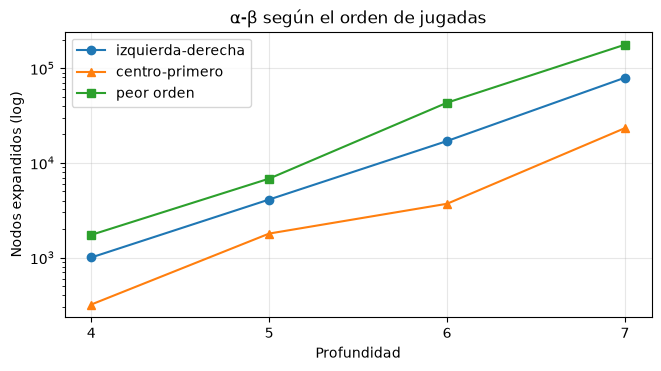

In [9]:
o = R['ordering']
orders = ['izquierda-derecha', 'centro-primero', 'peor orden']
depths = sorted({r['depth'] for r in o})
tabla(['Prof.'] + [f'Nodos {n}' for n in orders] + ['Mismo valor'],
      [(d, *[f"{next(r['nodes'] for r in o if r['depth'] == d and r['order'] == n):,}" for n in orders],
        len({r['value'] for r in o if r['depth'] == d}) == 1) for d in depths])
fig, ax = plt.subplots(figsize=(6.5, 3.6), layout='constrained')
for n, mk in zip(orders, 'o^s'):
    ax.plot(depths, [next(r['nodes'] for r in o if r['depth'] == d and r['order'] == n) for d in depths], marker=mk, label=n)
ax.set(yscale='log', xlabel='Profundidad', ylabel='Nodos expandidos (log)', title='α-β según el orden de jugadas', xticks=depths)
ax.legend(); ax.grid(alpha=.3); plt.show()

El valor es el mismo con los tres órdenes. Lo que cambia es el costo: a profundidad 7, el peor orden expande 177 443 nodos, izquierda-derecha 79 463 y centro-primero 23 316, unas 7,6 veces menos que el peor. En la escala logarítmica, la distancia entre las líneas crece con la profundidad. Por eso el orden es lo primero que optimizamos: decide hasta qué profundidad alcanza el presupuesto de 500 ms.

## 9. Garantía 2 (que falla a propósito): el efecto horizonte

In [10]:
tabla(['MAX prof.', 'MIN prof.', 'Ganador', 'Fichas al final'],
      [(r['depth_max'], r['depth_min'], r['winner'], r['plies']) for r in R['horizon']])
w, board = play(2, 5)
print(board)
print('ganador:', 'MAX (X, profundidad 2)' if w == MAX else 'MIN (O, profundidad 5)' if w == MIN else 'empate')

MAX prof.,MIN prof.,Ganador,Fichas al final
2,5,MIN,38
4,5,MIN,38
5,5,MIN,34
6,4,MAX,39


|X . X O O X O|
|O . O X X O X|
|X . X O O X O|
|O . O X X O X|
|X O X O O X O|
|O X O X X X O|
 0 1 2 3 4 5 6
ganador: MIN (O, profundidad 5)


**Lo que confirma la tabla:** en `play(2, 5)` y `play(4, 5)` gana el lado de profundidad 5 (MIN). En `play(6, 4)` gana el de profundidad 6 (MAX). Son los resultados que exige el test del horizonte, y coinciden con el notebook de la sesión A. En el tablero final de `play(2, 5)`, cada jugada de X era la mejor *dentro de lo que alcanzaba a ver*: la amenaza que lo derrota se resolvía más allá de su horizonte.

**El artefacto de `play(5, 5)`:** a igual profundidad gana el segundo jugador (MIN). Esto **no** es un efecto de horizonte, porque ambos ven lo mismo. Con juego perfecto, en Connect-4 gana el primer jugador. Este resultado habla de `evaluate()` y de que MAX debe comprometerse primero, no de la búsqueda. Por eso el test no lo verifica.

## 10. Diseño de nuestras mediciones

Medimos a los agentes con las mismas posiciones y con las mismas reglas:

- **Banco táctico** (`tactics.py`, semilla 20260928): 80 posiciones sin ganador en las que mueve `X`. Hay 10 de **victoria inmediata** y 10 de **bloqueo obligatorio** para cada tamaño de 6, 12, 18 y 24 fichas. Así cumplimos el mínimo del scorecard: cuatro tamaños y al menos diez instancias por tamaño. Las respuestas correctas las calcula el propio motor probando cada columna.
- **Mini torneo** (`tournament.py`): nuestro agente, α-β de profundidad fija 6 (el agente de referencia que menciona el starter), α-β de profundidad fija 4 y un agente aleatorio. Cada par juega 6 aperturas con ambos colores (72 partidas). Si una jugada supera 500 ms, esa partida se pierde.
- **Retador LLM** (`llm_challenger.py`): el mismo banco y partidas contra nuestro agente (sección 12).

**Casos sintéticos y fallos observados.** El banco táctico está construido por nosotros para probar dos habilidades concretas: ganar y bloquear. Un error ahí es un fallo **observado** del modelo en una posición **sintética**. Los textos inventados de `test_group.py` solo prueban el parser.

In [11]:
bank = tactics.load()
assert bank == tactics.generate()          # el banco se regenera idéntico
print(Counter((p['kind'], p['size']) for p in bank))
ej = next(p for p in bank if p['kind'] == 'block' and p['size'] == 12)
print(f"\nEjemplo {ej['id']} (bloqueo, respuesta = columna {ej['answers']}):")
print(tactics.board_from_moves(ej['moves']))

Counter({('block', 6): 10, ('win', 6): 10, ('win', 12): 10, ('block', 12): 10, ('win', 18): 10, ('block', 18): 10, ('win', 24): 10, ('block', 24): 10})

Ejemplo block-12-01 (bloqueo, respuesta = columna [4]):
|. . . . . . .|
|. . . . . . .|
|. . . . . . X|
|. . . . . . X|
|. O X X . . O|
|X O O O . O X|
 0 1 2 3 4 5 6


## 11. Resultados clásicos: banco táctico y mini torneo

In [12]:
at = R['agent_tactics']
rows = []
for size in tactics.SIZES:
    for kind in ('win', 'block'):
        grp = [r for r in at if r['size'] == size and r['kind'] == kind]
        rows.append((size, kind, pct(sum(r['correct'] for r in grp), len(grp)),
                     statistics.median(r['depth'] for r in grp), max(r['ms'] for r in grp)))
tabla(['Fichas', 'Tipo', 'Jugada correcta', 'Profundidad mediana', 'Máx. ms'], rows)
print('Total:', pct(sum(r['correct'] for r in at), len(at)), '| jugada más lenta:', max(r['ms'] for r in at), 'ms')

Fichas,Tipo,Jugada correcta,Profundidad mediana,Máx. ms
6,win,10/10 (100 %),1.00,0.80
6,block,10/10 (100 %),6.00,360.40
12,win,10/10 (100 %),1.00,1.30
12,block,10/10 (100 %),5.00,335.20
18,win,10/10 (100 %),1.00,1.40
18,block,10/10 (100 %),6.00,336.10
24,win,10/10 (100 %),1.00,1.40
24,block,10/10 (100 %),6.00,297.90


Total: 80/80 (100 %) | jugada más lenta: 360.4 ms


**Nuestro agente resolvió las 80 posiciones (100 %).** En las de victoria bastó la profundidad 1: el valor 10 000 detiene la búsqueda enseguida, y el tiempo es de unos 1-2 ms. En las de bloqueo, el agente siguió profundizando (profundidad mediana 5 a 6) porque ninguna jugada da un resultado forzado, y usó más tiempo, hasta unos 360 ms. Esto es la garantía en la práctica: una victoria o una amenaza de una jugada está siempre dentro del horizonte, así que el acierto no depende del tamaño del tablero.

In [13]:
T = R['tournament']
names = list(tournament.AGENTS)
score = {n: Counter() for n in names}
for r in T:
    for side, other in (('x', 'o'), ('o', 'x')):
        me = r[side]
        if r['winner'] == 'empate':
            score[me]['empates'] += 1
        elif r['winner'] == me:
            score[me]['victorias'] += 1
            if r['reason'] == 'tiempo': score[me]['ganadas por tiempo del rival'] += 1
        else:
            score[me]['derrotas'] += 1
            if r['reason'] == 'tiempo': score[me]['perdidas por tiempo'] += 1
maxms = {n: max([r['x_max_ms'] for r in T if r['x'] == n] + [r['o_max_ms'] for r in T if r['o'] == n]) for n in names}
tabla(['Agente', 'Victorias', 'Empates', 'Derrotas', 'Perdidas por tiempo', 'Ganadas por tiempo del rival', 'Jugada más lenta (ms)'],
      [(n, score[n]['victorias'], score[n]['empates'], score[n]['derrotas'], score[n]['perdidas por tiempo'],
        score[n]['ganadas por tiempo del rival'], maxms[n]) for n in names])
pairs = []
for i, a in enumerate(names):
    for b in names[i + 1:]:
        gs = [r for r in T if {r['x'], r['o']} == {a, b}]
        pairs.append((a, b, sum(r['winner'] == a for r in gs), sum(r['winner'] == 'empate' for r in gs), sum(r['winner'] == b for r in gs),
                      sum(r['reason'] == 'tiempo' for r in gs)))
tabla(['Agente A', 'Agente B', 'Gana A', 'Empates', 'Gana B', 'Decididas por tiempo'], pairs)

Agente,Victorias,Empates,Derrotas,Perdidas por tiempo,Ganadas por tiempo del rival,Jugada más lenta (ms)
ID-αβ (nuestro),28,0,8,0,11,400.10
αβ fijo d6,3,0,33,33,0,"1,368.90"
αβ fijo d4,31,0,5,0,12,121.90
aleatorio,10,0,26,0,10,0.00


Agente A,Agente B,Gana A,Empates,Gana B,Decididas por tiempo
ID-αβ (nuestro),αβ fijo d6,11,0,1,11
ID-αβ (nuestro),αβ fijo d4,5,0,7,0
ID-αβ (nuestro),aleatorio,12,0,0,0
αβ fijo d6,αβ fijo d4,0,0,12,12
αβ fijo d6,aleatorio,2,0,10,10
αβ fijo d4,aleatorio,12,0,0,0


**Lo que muestra el torneo (72 partidas, corrida guardada):**
- **Nuestro agente nunca superó los 500 ms.** Su jugada más lenta fue de unos 400 ms, justo el corte duro del 80 %. No perdió ninguna partida por tiempo.
- **`αβ fijo d6` perdió 11 de 12 partidas contra nuestro agente, y todas esas derrotas fueron por tiempo.** Contra `d4` y contra el aleatorio también perdió casi todo por tiempo. Su jugada más lenta superó el segundo. Es el resultado que anticipa la consigna: un agente de profundidad fija "wastes budget or forfeits". Juega "mejor" jugada por jugada, pero en algún momento se pasa del límite.
- **Contra el aleatorio, nuestro agente ganó 12 de 12.**
- **El resultado que no esperábamos: contra `αβ fijo d4`, nuestro agente perdió 7 y ganó 5**, aunque busca a más profundidad (mediana 5 a 6 en el banco). La consigna dice que la profundidad le gana al conocimiento a esta escala, así que lo investigamos en las dos celdas siguientes en vez de ocultarlo.

La corrida guardada de la versión 1 (`resultados_v1_sin_corte_duro/`) tampoco fue favorable: 6 victorias, 1 empate y 5 derrotas contra `d4`, dos de ellas por tiempo. Ese emparejamiento nunca muestra una ventaja clara de nuestro agente.

In [14]:
# Control: ¿la profundidad gana cuando quitamos el reloj? α-β fijo d6 vs d4, mismas aperturas, sin derrota por tiempo.
D = R['depth_no_clock']
res = Counter(r['winner'] for r in D)
tabla(['Apertura', 'X', 'O', 'Ganador', 'Jugadas'], [(r['opening'], r['x'], r['o'], r['winner'], r['plies']) for r in D])
print('Resumen sin reloj:', dict(res))

Apertura,X,O,Ganador,Jugadas
33,αβ fijo d6,αβ fijo d4,αβ fijo d4,36
33,αβ fijo d4,αβ fijo d6,αβ fijo d4,37
14,αβ fijo d6,αβ fijo d4,αβ fijo d6,37
14,αβ fijo d4,αβ fijo d6,αβ fijo d6,36
50,αβ fijo d6,αβ fijo d4,αβ fijo d6,23
50,αβ fijo d4,αβ fijo d6,αβ fijo d4,35
12,αβ fijo d6,αβ fijo d4,αβ fijo d6,33
12,αβ fijo d4,αβ fijo d6,empate,42
56,αβ fijo d6,αβ fijo d4,αβ fijo d6,33
56,αβ fijo d4,αβ fijo d6,αβ fijo d4,35


Resumen sin reloj: {'αβ fijo d4': 5, 'αβ fijo d6': 6, 'empate': 1}


**Control sin reloj:** incluso sin la regla de tiempo, `αβ fijo d6` le gana a `αβ fijo d4` apenas 6 a 5 (con 1 empate) en estas 12 partidas. **Con este `evaluate()`, dos plies de profundidad extra no dan una ventaja clara.** Nuestra interpretación, que es una hipótesis y no algo medido: la evaluación puntúa ventanas de 4 casillas sin considerar la paridad de las filas ni qué amenazas se pueden jugar realmente, y a 4-6 plies casi todas las partidas se deciden por amenazas más profundas que ambos horizontes. Es el mismo tipo de artefacto que la consigna señala en `play(5, 5)`. Con 12 partidas por emparejamiento tampoco podemos distinguir un 7-5 de un empate estadístico.

**Qué afirmamos y qué no:** afirmamos que nuestro agente cumple el reloj y que la profundidad fija sin control de tiempo pierde por tiempo. **No** afirmamos que nuestro agente sea más fuerte que `d4` en el tablero: nuestros datos no lo sostienen.

In [15]:
# ¿Nuestro agente es determinista? Repetimos ahora sus jugadas de una partida guardada.
# Elegimos la primera partida que nuestro agente perdió en el tablero (no por tiempo).
lost = next(r for r in T if r['reason'] == 'cuatro en línea' and 'nuestro' in r['x'] + r['o'] and 'nuestro' not in r['winner'])
ours = MAX if 'nuestro' in lost['x'] else MIN
moves = list(map(int, lost['moves'].split()))
b, p, diffs, seen_loss = Connect4(), MAX, [], None
for i, c in enumerate(moves):
    if p == ours and i >= 2:
        m, info = s.search_profile(tournament.as_max(b, p), 500)
        if m != c: diffs.append((i, c, m))
        if seen_loss is None and any(v <= -10_000 for _, v, *_ in info): seen_loss = (i, info[-1][0])
    b.push(c, p); p = -p
print(f"Partida {lost['x']} (X) vs {lost['o']} (O), apertura {lost['opening']}: ganó {lost['winner']} en {lost['plies']} jugadas")
print('Jugadas de nuestro agente que HOY serían distintas (jugada, guardada, ahora):', diffs or 'ninguna')
print('Primera jugada en que nuestro agente ya ve la derrota forzada (jugada, profundidad):', seen_loss)

Partida ID-αβ (nuestro) (X) vs αβ fijo d6 (O), apertura 12: ganó αβ fijo d6 en 40 jugadas
Jugadas de nuestro agente que HOY serían distintas (jugada, guardada, ahora): [(4, 1, 3), (6, 3, 2)]
Primera jugada en que nuestro agente ya ve la derrota forzada (jugada, profundidad): (30, 8)


**Dos observaciones:**
1. Al repetir las jugadas de nuestro agente sobre la misma partida, algunas pueden salir distintas. La profundidad alcanzada depende del reloj, así que **nuestro agente no es determinista**, a diferencia de un α-β de profundidad fija. Para el scorecard, "mismo valor a la misma profundidad" es una garantía; "misma jugada en cada corrida" no lo es.
2. El agente descubre la derrota forzada solo varias jugadas antes del final. La posición perdedora se formó más allá de su horizonte, igual que en la sección 9.

## 12. El retador LLM: prompt exacto y configuración

Usamos **exactamente** el prompt de la consigna. `{board}` es `str(board)` y `{legal}` es `legal_moves()`. El LLM siempre es `X`: cuando juega con MIN, le entregamos el tablero con los colores invertidos.

In [16]:
print(llm.PROMPT)
print('\n--- Ejemplo real de prompt enviado (posición win-12-01) ---')
print(llm.make_prompt(tactics.board_from_moves(next(p for p in bank if p['id'] == 'win-12-01')['moves'])))

Connect-4. You are 'X'. Columns numbered 0-6, left to right.
Board (bottom row last):
{board}
Legal columns: {legal}
Reply with one column number and nothing else.

--- Ejemplo real de prompt enviado (posición win-12-01) ---
Connect-4. You are 'X'. Columns numbered 0-6, left to right.
Board (bottom row last):
|. . . . . . .|
|. . . . . . .|
|. . . . . . .|
|. O X . . . .|
|. O X . O . X|
|O X X . O X O|
 0 1 2 3 4 5 6
Legal columns: [0, 1, 2, 3, 4, 5, 6]
Reply with one column number and nothing else.


| Parámetro | Valor | Por qué |
|---|---|---|
| Backend | Ollama 0.34.4, local, en la laptop del grupo | Es el Backend A de `resources/setup.md` |
| Modelo principal | `qwen2.5:3b` | Es el modelo por defecto del harness y de `setup.md` |
| Modelo de comparación | `qwen2.5:1.5b` (solo banco táctico) | Es el modelo que usamos en las semanas 0 a 2 |
| Temperatura / semilla | 0 / 0 en la corrida principal | Es el valor reproducible por defecto del harness |
| Validación | Cada respuesta se compara con `legal_moves()`. Un reintento con otra semilla, y si falla, *fallback* centro-primero | La consigna dice: "validate + retry the rest" |
| Caché | `.llm_cache/`, clave = (backend, modelo, prompt, temperatura, semilla) | Es la evidencia exigida por `setup.md`; se versiona |
| Registro | `resultados_llm/llm_calls.jsonl`: una línea por llamada, con texto, tiempo, tokens y `cached` | Permite auditar cada número de esta sección |

**No le creemos al modelo:** la jugada que cuenta es la que verificamos con el motor. Separamos además la lectura **estricta** (la respuesta es solo un número, como pide el prompt) de la **tolerante** (el primer entero dentro del texto).

In [17]:
calls = [json.loads(l) for l in (ROOT / 'resultados_llm/llm_calls.jsonl').read_text(encoding='utf-8').splitlines()]
lm = json.loads((ROOT / 'resultados_llm/metadata.json').read_text(encoding='utf-8'))
tabla(['Experimento', 'Modelo', 'Llamadas', 'Inferencias nuevas', 'Aciertos de caché', 'Mediana s', 'p95 s'],
      [(e, m, len(c), sum(not x['cached'] for x in c), sum(x['cached'] for x in c),
        round(statistics.median(x['elapsed'] for x in c if not x['cached']), 2),
        round(sorted(x['elapsed'] for x in c if not x['cached'])[int(.95 * sum(not x['cached'] for x in c)) - 1], 2))
       for (e, m), c in sorted(((k, [x for x in calls if (x['experiment'], x['model']) == k])
                               for k in {(x['experiment'], x['model']) for x in calls}), key=lambda kv: kv[0])])
print('Corridas registradas:', {m: v['last_run_utc'] for m, v in lm['runs'].items()})

Experimento,Modelo,Llamadas,Inferencias nuevas,Aciertos de caché,Mediana s,p95 s
games,qwen2.5:3b,40,40,0,2.24,2.35
repro,qwen2.5:3b,200,200,0,2.18,2.31
tactics,qwen2.5:1.5b,81,81,0,2.19,2.26
tactics,qwen2.5:3b,80,80,0,2.22,2.30


Corridas registradas: {'qwen2.5:3b': '2026-09-28T19:07:48.270291+00:00', 'qwen2.5:1.5b': '2026-09-28T19:10:48.296789+00:00'}


**Qué muestra la tabla:** hicimos 401 llamadas y **todas fueron inferencias nuevas**. Ninguna se leyó de la caché en el momento de medir. La columna 0 del conteo de caché es la evidencia de que no repetimos el error de la semana 2. Cada llamada tarda alrededor de 2,2 s, frente a unos cientos de milisegundos de nuestro agente, que además dedica ese tiempo a buscar. El total de llamadas del banco con `qwen2.5:1.5b` es 81 y no 80 porque una respuesta ilegal provocó un reintento (sección 16).

Si ejecutamos de nuevo `llm_challenger.py`, las respuestas vendrán de la caché. Por eso el notebook **lee** los CSV y el registro de la corrida original, en lugar de volver a llamar al modelo.

## 13. El LLM frente al banco táctico

In [18]:
def load_csv(name):
    with (ROOT / 'resultados_llm' / name).open(encoding='utf-8', newline='') as f:
        return list(csv.DictReader(f))
L3, L15 = load_csv('llm_tactics_3b.csv'), load_csv('llm_tactics_1.5b.csv')
rows = []
for size in tactics.SIZES:
    for kind in ('win', 'block'):
        a = [r for r in at if r['size'] == size and r['kind'] == kind]
        l3 = [r for r in L3 if int(r['size']) == size and r['kind'] == kind]
        l1 = [r for r in L15 if int(r['size']) == size and r['kind'] == kind]
        rows.append((size, kind, pct(sum(r['correct'] for r in a), len(a)),
                     pct(sum(int(r['correct_first']) for r in l3), len(l3)),
                     pct(sum(int(r['first_legal']) for r in l3), len(l3)),
                     pct(sum(int(r['correct_first']) for r in l1), len(l1)),
                     pct(sum(int(r['first_legal']) for r in l1), len(l1))))
tabla(['Fichas', 'Tipo', 'α-β correcto', 'qwen 3b correcto', 'qwen 3b legal', 'qwen 1.5b correcto', 'qwen 1.5b legal'], rows)
for name, L in [('3b', L3), ('1.5b', L15)]:
    print(f"qwen2.5:{name}: correcto {pct(sum(int(r['correct_first']) for r in L), len(L))}, "
          f"legal al primer intento {pct(sum(int(r['first_legal']) for r in L), len(L))}, "
          f"respuesta estricta {pct(sum(int(r['first_strict']) for r in L), len(L))}, "
          f"fallback {sum(int(r['fallback']) for r in L)}")

Fichas,Tipo,α-β correcto,qwen 3b correcto,qwen 3b legal,qwen 1.5b correcto,qwen 1.5b legal
6,win,10/10 (100 %),3/10 (30 %),10/10 (100 %),1/10 (10 %),10/10 (100 %)
6,block,10/10 (100 %),1/10 (10 %),10/10 (100 %),0/10 (0 %),10/10 (100 %)
12,win,10/10 (100 %),2/10 (20 %),10/10 (100 %),1/10 (10 %),10/10 (100 %)
12,block,10/10 (100 %),0/10 (0 %),10/10 (100 %),2/10 (20 %),10/10 (100 %)
18,win,10/10 (100 %),3/10 (30 %),10/10 (100 %),0/10 (0 %),10/10 (100 %)
18,block,10/10 (100 %),4/10 (40 %),10/10 (100 %),2/10 (20 %),10/10 (100 %)
24,win,10/10 (100 %),3/10 (30 %),10/10 (100 %),0/10 (0 %),9/10 (90 %)
24,block,10/10 (100 %),2/10 (20 %),10/10 (100 %),2/10 (20 %),10/10 (100 %)


qwen2.5:3b: correcto 18/80 (22 %), legal al primer intento 80/80 (100 %), respuesta estricta 80/80 (100 %), fallback 0
qwen2.5:1.5b: correcto 8/80 (10 %), legal al primer intento 79/80 (99 %), respuesta estricta 80/80 (100 %), fallback 1


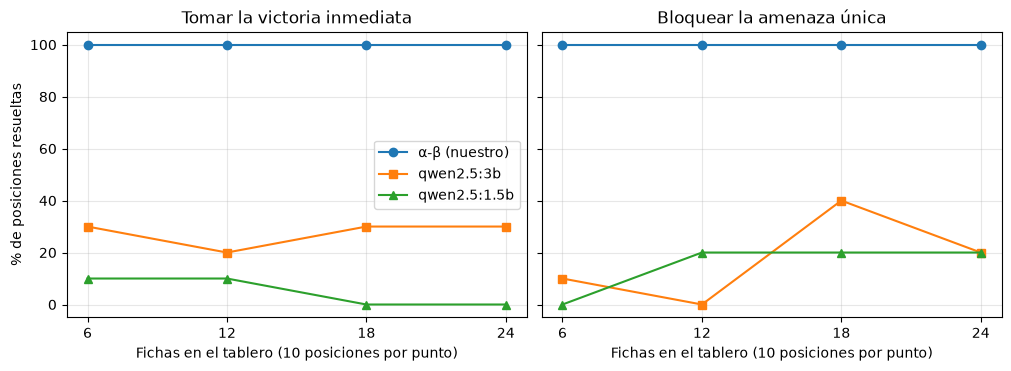

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout='constrained', sharey=True)
for ax, kind, title in zip(axes, ('win', 'block'), ('Tomar la victoria inmediata', 'Bloquear la amenaza única')):
    for label, data, key, mk in [('α-β (nuestro)', at, 'correct', 'o'), ('qwen2.5:3b', L3, 'correct_first', 's'),
                                 ('qwen2.5:1.5b', L15, 'correct_first', '^')]:
        ys = [100 * statistics.mean(int(r[key]) for r in data if int(r['size']) == z and r['kind'] == kind) for z in tactics.SIZES]
        ax.plot(tactics.SIZES, ys, marker=mk, label=label)
    ax.set(title=title, xlabel='Fichas en el tablero (10 posiciones por punto)', xticks=tactics.SIZES, ylim=(-5, 105))
    ax.grid(alpha=.3)
axes[0].set_ylabel('% de posiciones resueltas'); axes[0].legend()
fig.savefig(ROOT / 'resultados_llm/scaling.png', dpi=130)
plt.show()

**Lo que medimos:**
- **Legalidad:** `qwen2.5:3b` respondió **siempre** con un solo número legal (80/80, todas con lectura estricta). `qwen2.5:1.5b` dio una respuesta ilegal: eligió la columna 4, que estaba llena.
- **Jugada correcta:** `qwen2.5:3b` tomó la victoria o bloqueó en **18/80 posiciones (22,5 %)**. `qwen2.5:1.5b` lo hizo en **8/80 (10 %)**. Nuestro agente resolvió 80/80.
- **Por tipo:** con `3b`, tomó la victoria inmediata en 11 de 40 posiciones y bloqueó en 7 de 40.

**Escalamiento:** la consigna del scorecard espera una curva que se desploma a medida que crece el problema. **En nuestros datos no aparece ese desplome:** el LLM ya es bajo con 6 fichas, y los aciertos por tamaño (3, 2, 3 y 3 victorias; 1, 0, 4 y 2 bloqueos de 10) varían sin una tendencia clara. Con 10 posiciones por punto, una diferencia de 1 a 4 aciertos está dentro de lo que puede producir el azar. No hay "precipicio" porque el modelo nunca estuvo arriba. La línea de α-β es plana en 100 %, como predice la garantía: ganar o bloquear en una jugada está siempre dentro de su horizonte.

In [20]:
# ¿Qué columnas elige el LLM? Si responde casi siempre lo mismo, no está leyendo el tablero.
for name, L in [('3b', L3), ('1.5b', L15)]:
    c = Counter(r['first_parsed'] for r in L)
    print(f'qwen2.5:{name} — columnas elegidas en las 80 posiciones:', dict(sorted(c.items(), key=lambda kv: -kv[1])))
print('Columnas correctas en el banco:', dict(Counter(a for p in bank for a in p['answers'])))
# Dos referencias sin inteligencia, calculadas sobre el mismo banco (no son corridas del LLM):
azar = sum(len(p['answers']) / len(tactics.board_from_moves(p['moves']).legal_moves()) for p in bank)
centro = sum(next(c for c in CENTER_FIRST if c in tactics.board_from_moves(p['moves']).legal_moves()) in p['answers'] for p in bank)
print(f'Referencia: jugada legal al azar acierta en promedio {azar:.1f}/80 ({100 * azar / 80:.0f} %)')
print(f'Referencia: jugar siempre la columna legal más central acierta {centro}/80 ({100 * centro / 80:.0f} %)')

qwen2.5:3b — columnas elegidas en las 80 posiciones: {'4': 36, '3': 20, '6': 12, '5': 6, '2': 3, '1': 3}
qwen2.5:1.5b — columnas elegidas en las 80 posiciones: {'4': 70, '5': 7, '2': 2, '3': 1}
Columnas correctas en el banco: {5: 10, 3: 25, 4: 7, 1: 14, 2: 14, 6: 9, 0: 2}
Referencia: jugada legal al azar acierta en promedio 12.3/80 (15 %)
Referencia: jugar siempre la columna legal más central acierta 28/80 (35 %)


**¿Lee el tablero?** Las respuestas se concentran en las columnas centrales: `3b` eligió la 4 o la 3 en 56 de 80 posiciones, y `1.5b` eligió la 4 en 70 de 80. Las dos referencias calculadas arriba sobre el mismo banco, que no son corridas del LLM, permiten ponerlo en contexto. Una jugada legal al azar acierta en promedio 12,3/80 (15 %). Jugar siempre la columna legal más central acierta 28/80 (35 %). **`qwen2.5:3b` (22,5 %) supera al azar, pero queda por debajo de una regla fija que no mira el tablero. `qwen2.5:1.5b` (10 %) queda incluso por debajo del azar.** Nuestra lectura es una inferencia y no algo medido directamente: el modelo reproduce un patrón conocido de Connect-4 ("juega al centro") en lugar de calcular sobre la posición, y ni siquiera aplica ese patrón de forma consistente.

## 14. Reproducibilidad con inferencias independientes

En la semana 2 cometimos un error: nuestras "cinco repeticiones" eran la misma llamada leída cinco veces de la caché. Aquí lo evitamos así:

- tomamos 20 posiciones fijas (3 de victoria y 2 de bloqueo por tamaño);
- cada una se pide con **semillas 1 a 5**, distintas de la semilla 0 de la corrida principal, a **temperatura 0** y a **temperatura 0.7**, lo que da 200 llamadas;
- como la semilla forma parte de la clave de caché, cada llamada fue una **inferencia nueva** la primera vez. La celda siguiente lo comprueba en el registro, en lugar de suponerlo.

In [21]:
rep = load_csv('llm_repro_3b.csv')
assert all(r['cached'] == '0' for r in rep), 'alguna repetición salió de la caché'
rep_calls = [x for x in calls if x['experiment'] == 'repro']
print('Repeticiones medidas:', len(rep), '| todas fueron inferencias nuevas (cached=False):', all(not x['cached'] for x in rep_calls))
rows = []
for temp in ('0.0', '0.7'):
    grp = defaultdict(list)
    for r in rep:
        if r['temperature'] == temp:
            grp[r['id']].append(r['parsed'])
    distinct = [len(set(v)) for v in grp.values()]
    rows.append((temp, len(grp), Counter(distinct).most_common(), statistics.mean(distinct),
                 pct(sum(int(r['correct']) for r in rep if r['temperature'] == temp), sum(r['temperature'] == temp for r in rep))))
tabla(['Temperatura', 'Posiciones', 'Respuestas distintas por posición: (cuántas, frecuencia)', 'Media distintas', 'Correctas'], rows)

Repeticiones medidas: 200 | todas fueron inferencias nuevas (cached=False): True


Temperatura,Posiciones,"Respuestas distintas por posición: (cuántas, frecuencia)",Media distintas,Correctas
0.0,20,"[(1, 18), (2, 2)]",1.10,30/100 (30 %)
0.7,20,"[(2, 12), (3, 5), (1, 3)]",2.10,24/100 (24 %)


**Resultado:**
- **Temperatura 0:** en 18 de las 20 posiciones, las cinco inferencias independientes dieron la misma columna. En 2 posiciones aparecieron dos respuestas distintas. Con decodificación *greedy* esperábamos una sola respuesta en todas; esta pequeña variación se debe probablemente a diferencias numéricas en la ejecución de Ollama. Es una hipótesis que no comprobamos. Además, en 17 de las 20 posiciones las cinco repeticiones coinciden con la respuesta de la corrida principal (semilla 0).
- **Temperatura 0.7:** solo 3 de las 20 posiciones mantienen una única respuesta. Lo más común son 2 o 3 columnas distintas en 5 intentos, y el acierto baja de 30/100 a 24/100.

La reproducibilidad del LLM a temperatura 0 es **alta pero no perfecta**, y no la podemos asumir: hay que medirla. Como en cada posición existe una única respuesta correcta verificable, que el modelo repita la misma respuesta no la vuelve correcta: repite un error con la misma confianza.

## 15. Partidas: LLM contra nuestro agente

Jugamos 4 aperturas con ambos colores (8 partidas). Nuestro agente mantiene su reloj de 500 ms. Al LLM **no** le aplicamos la regla de tiempo: si la aplicáramos perdería todas las partidas por latencia, y no podríamos observar cómo juega. Esto lo declaramos en la sección 18.

En cada turno del LLM registramos si tenía una victoria inmediata o una única amenaza que bloquear, y si la aprovechó.

In [22]:
G, GM = load_csv('llm_games_3b.csv'), load_csv('llm_game_moves_3b.csv')
tabla(['Partida', 'LLM juega', 'Apertura', 'Ganador', 'Jugadas'], [(r['game'], r['llm_color'], r['opening'], r['winner'], r['plies']) for r in G])
wins_avail = [m for m in GM if m['had_win']]
blocks_needed = [m for m in GM if not m['had_win'] and len(m['threats'].split()) == 1]
print(f"Turnos del LLM: {len(GM)} | legal al primer intento: {pct(sum(int(m['first_legal']) for m in GM), len(GM))} | fallbacks: {sum(int(m['fallback']) for m in GM)}")
print(f"Victorias inmediatas disponibles: {len(wins_avail)}, perdidas: {sum(int(m['missed_win']) for m in GM)}")
print(f"Bloqueos obligatorios: {len(blocks_needed)}, no bloqueados: {sum(int(m['missed_block']) for m in GM)}")
lat = sorted(float(m['seconds']) for m in GM)
ours = [ms for r in T for ms in ([r['x_max_ms']] if 'nuestro' in r['x'] else []) + ([r['o_max_ms']] if 'nuestro' in r['o'] else [])]
print(f"Latencia LLM por jugada: mediana {statistics.median(lat):.2f} s, p95 {lat[int(.95 * len(lat)) - 1]:.2f} s")

Partida,LLM juega,Apertura,Ganador,Jugadas
g0X,X,33,agente,12
g0O,O,33,agente,13
g1X,X,14,agente,10
g1O,O,14,agente,15
g2X,X,50,agente,12
g2O,O,50,agente,9
g3X,X,12,agente,12
g3O,O,12,agente,17


Turnos del LLM: 40 | legal al primer intento: 40/40 (100 %) | fallbacks: 0
Victorias inmediatas disponibles: 0, perdidas: 0
Bloqueos obligatorios: 7, no bloqueados: 7
Latencia LLM por jugada: mediana 2.24 s, p95 2.35 s


**Resultado:** nuestro agente ganó las **8 partidas**, entre 9 y 17 jugadas. El LLM jugó siempre una columna legal (40/40 turnos, sin *fallback*). En estas partidas **nunca tuvo una victoria inmediata disponible**, así que ahí no pudimos medir "victorias perdidas": esa medición sale del banco táctico. En cambio, tuvo **7 turnos en los que debía bloquear una amenaza única y no bloqueó ninguna**. Hubo además un turno con dos amenazas simultáneas, que ya no se podían bloquear. El agente ganó en la jugada siguiente a cada uno de esos errores.

Estas partidas se jugaron contra la versión 1 de nuestro agente, antes de añadir el corte duro. La búsqueda es la misma.

La latencia del LLM, de alrededor de 2,2 s por jugada, es unas 4 veces el límite del torneo. Con la regla de 500 ms, el LLM habría perdido por tiempo en su primera jugada.

## 16. Failure Atlas: fallos observados

Estos casos salen de las corridas guardadas, no de ejemplos inventados. El registro completo, con el tablero exacto para reproducirlos, está en `failure_atlas.md`.

In [23]:
ex_win = next(r for r in L3 if r['kind'] == 'win' and r['correct_first'] == '0' and r['first_legal'] == '1')
p = next(p for p in bank if p['id'] == ex_win['id'])
print(f"[{ex_win['id']}] victoria disponible en {p['answers']}; qwen2.5:3b respondió {ex_win['raw']!r}")
print(tactics.board_from_moves(p['moves']))
missed = [m for m in GM if m['missed_win'] == '1' or m['missed_block'] == '1']
if missed:
    m = missed[0]
    print(f"\n[{m['game']} jugada {m['ply']}] en partida: victoria en [{m['had_win']}] / amenaza en [{m['threats']}]; el LLM jugó {m['move']} ({m['raw']!r})")
    print(m['board_seen'])

[win-06-01] victoria disponible en [3]; qwen2.5:3b respondió '4'
|. . . . . . .|
|. . . . . . .|
|. . . . . . .|
|. . . . . . .|
|. . . . . . .|
|O O O . X X X|
 0 1 2 3 4 5 6

[g0X jugada 10] en partida: victoria en [] / amenaza en [3]; el LLM jugó 4 ('4')
|. . . . . . .|
|. . . . X . .|
|. . . O X . .|
|. . . O O . .|
|. . . O X . .|
|. . . X X O .|
 0 1 2 3 4 5 6


## 17. Scorecard del duelo (resources/duel-scorecard.md)

In [24]:
n3 = len(L3)
c3 = sum(int(r['correct_first']) for r in L3)
tac_ms = sorted(r['ms'] for r in at)
lat3 = sorted(x['elapsed'] for x in calls if x['model'] == 'qwen2.5:3b' and x['experiment'] == 'tactics' and not x['cached'])
tok = [x['eval_count'] + x['prompt_eval_count'] for x in calls if x['model'] == 'qwen2.5:3b' and x['experiment'] == 'tactics' and x['eval_count']]
rep0 = defaultdict(set)
for r in rep:
    if r['temperature'] == '0.0': rep0[r['id']].add(r['parsed'])
tabla(['Eje', 'Clásico: α-β + profundización iterativa', 'LLM: qwen2.5:3b', 'Evidencia'], [
    ('Correctness', pct(sum(r['correct'] for r in at), len(at)) + ' en el banco táctico', pct(c3, n3) + ' en el banco táctico', 'agent_tactics.csv, llm_tactics_3b.csv'),
    ('Guarantee', 'Mismo valor que minimax a igual profundidad; ve toda victoria o amenaza dentro de su horizonte', 'Ninguna', 'Sección 7, tests'),
    ('Cost', f"mediana {statistics.median(r['nodes'] for r in at):,.0f} nodos por posición", f'mediana {statistics.median(tok):,.0f} tokens (prompt + respuesta)', 'agent_tactics.csv, llm_calls.jsonl'),
    ('Latency', f'{statistics.median(tac_ms):.0f} ms mediana / {tac_ms[int(.95 * len(tac_ms)) - 1]:.0f} ms p95', f'{statistics.median(lat3):.2f} s / {lat3[int(.95 * len(lat3)) - 1]:.2f} s', 'agent_tactics.csv, llm_calls.jsonl'),
    ('Reproducibility', 'Mismo valor a profundidad fija; la jugada puede variar con el reloj (sección 11)',
     f'T=0: media de {statistics.mean(len(v) for v in rep0.values()):.2f} respuestas distintas en 5 inferencias', 'llm_repro_3b.csv'),
    ('Scaling', 'Plano en el banco (100 % en los 4 tamaños); el costo crece con la profundidad', 'Ver gráfica de la sección 13', 'resultados_llm/scaling.png'),
    ('Interpretability', 'Valor y profundidad de cada iteración: certificado verificable', 'Un número sin justificación', '—'),
    ('Failure mode', 'Horizonte: pierde por amenazas más allá de su profundidad; con profundidad fija, pierde por tiempo', 'Seguro pero equivocado: jugada legal que ignora la victoria o la amenaza', 'failure_atlas.md'),
])

Eje,Clásico: α-β + profundización iterativa,LLM: qwen2.5:3b,Evidencia
Correctness,80/80 (100 %) en el banco táctico,18/80 (22 %) en el banco táctico,"agent_tactics.csv, llm_tactics_3b.csv"
Guarantee,Mismo valor que minimax a igual profundidad; ve toda victoria o amenaza dentro de su horizonte,Ninguna,"Sección 7, tests"
Cost,mediana 26 nodos por posición,mediana 154 tokens (prompt + respuesta),"agent_tactics.csv, llm_calls.jsonl"
Latency,3 ms mediana / 298 ms p95,2.22 s / 2.30 s,"agent_tactics.csv, llm_calls.jsonl"
Reproducibility,Mismo valor a profundidad fija; la jugada puede variar con el reloj (sección 11),T=0: media de 1.10 respuestas distintas en 5 inferencias,llm_repro_3b.csv
Scaling,Plano en el banco (100 % en los 4 tamaños); el costo crece con la profundidad,Ver gráfica de la sección 13,resultados_llm/scaling.png
Interpretability,Valor y profundidad de cada iteración: certificado verificable,Un número sin justificación,—
Failure mode,"Horizonte: pierde por amenazas más allá de su profundidad; con profundidad fija, pierde por tiempo",Seguro pero equivocado: jugada legal que ignora la victoria o la amenaza,failure_atlas.md


Cada fila tiene su evidencia en un archivo de `resultados/` o `resultados_llm/`. Según la escala de puntuación del scorecard, la mayoría de los ejes están medidos **en varias instancias y cuatro tamaños**. La reproducibilidad del LLM se midió con inferencias independientes, y el costo se da en unidades distintas (nodos frente a tokens), porque no hay una moneda común honesta entre ambos.

## 18. Where we may have been unfair

- **Mismo tablero, pero no la misma información.** Nuestro agente recibe la posición como estructura de datos y un simulador exacto; el LLM recibe texto. Así lo plantea la consigna, pero es una diferencia de fondo.
- **Prompt sin ajustar.** Usamos el prompt exacto del plan sin probar variantes (explicar las reglas, pedir primero una jugada ganadora, marcar la última ficha). En cambio, sí ajustamos el agente clásico (`SAFETY`, el corte duro) después de verlo fallar. Esa asimetría favorece al clásico.
- **Modelos pequeños.** `qwen2.5:3b` y `1.5b` son modelos de laptop. El 3b acierta más que el 1.5b (22,5 % frente a 10 %), pero con solo dos tamaños no podemos extrapolar qué haría un modelo de frontera. Sin medirlo, no lo sabemos.
- **Banco sintético.** Las posiciones vienen de partidas aleatorias, no de partidas entre buenos jugadores. Puede que el LLM reconozca mejor patrones de partidas "naturales", o peor.
- **Tamaño como número de fichas.** Es una aproximación a la dificultad elegida por nosotros, no una medida estándar.
- **Reloj solo para el agente clásico.** En las partidas no aplicamos los 500 ms al LLM. Si lo hiciéramos, habría perdido todas por tiempo.
- **Partidas contra la versión 1 del agente.** Las partidas LLM se jugaron antes de añadir el corte duro. La búsqueda es la misma; solo cambia la protección de tiempo.
- **Una sola máquina.** Todos los tiempos son de una laptop (AMD Ryzen AI 9 HX 370), con OneDrive y Ollama abiertos. Entre corridas vimos variaciones de tiempo de hasta 2,5 veces en la misma búsqueda.
- **Tiempo humano.** No medimos cuánto costó escribir el agente frente a escribir el prompt.

## 19. Conclusiones

1. **α-β es exacto.** Devolvió el mismo valor que minimax en todas las profundidades medidas, con hasta 36 veces menos nodos gracias al orden centro-primero. El orden cambia el costo y nunca la respuesta.
2. **El reloj define el agente.** Nuestra primera versión, que solo estimaba el tiempo, perdió partidas por tiempo. Con el corte duro no volvió a pasar. `αβ fijo d6` perdió casi todas sus partidas por tiempo. En un torneo con reloj, *cumplir el tiempo* es parte de la corrección.
3. **La profundidad no bastó para ganar a `d4`.** Con este `evaluate()`, ni nuestro agente ni `d6` sin reloj le ganaron claramente a `d4`. No confirmamos "depth beats knowledge" para este motor; lo dejamos como resultado abierto.
4. **El LLM no busca.** `qwen2.5:3b` jugó siempre columnas legales, pero tomó la victoria o bloqueó en apenas 22,5 % del banco táctico. Eso está por debajo de jugar siempre al centro (35 %). En las partidas no bloqueó ninguna de las 7 amenazas únicas y perdió las 8 partidas. El problema no es el formato de la respuesta sino la decisión.
5. **No hubo "precipicio", porque nunca estuvo arriba.** La curva del LLM es baja y ruidosa desde 6 fichas; la de α-β es plana en 100 %.
6. **Arquitectura.** Para un juego con reglas formales, el LLM es un mal *motor*. La búsqueda con garantía es la que decide bien. Esto es consistente con la tesis del curso: si el LLM sirve de algo aquí, es como interfaz, no como motor. Y con Ruoss et al. (2024): cuando un modelo juega bien sin buscar, es porque la búsqueda se hizo durante su entrenamiento.

## 20. Preguntas para preparar la defensa

**¿Por qué α-β no es una aproximación?** Solo descarta ramas cuyo valor ya no puede cambiar la decisión de la raíz: si `alpha >= beta`, el jugador de arriba nunca elegiría esa rama.

**¿Por qué el orden no cambia el valor?** Porque cambia qué ramas se podan, pero el máximo y el mínimo sobre los mismos hijos no cambian. Lo comprobamos en la sección 8.

**¿Por qué profundización iterativa y no profundidad fija?** Porque con profundidad fija el tiempo por jugada varía mucho según la posición. `αβ fijo d6` perdió partidas por tiempo; nuestro agente no.

**¿Repetir las profundidades 1…d-1 no desperdicia trabajo?** Cuesta poco frente a la última profundidad, porque cada una crece varias veces (tabla de la sección 4), y además deja la mejor jugada previa al inicio del orden.

**¿Por qué `play(5, 5)` no demuestra el efecto horizonte?** Porque ambos lados ven lo mismo. El resultado depende de `evaluate()` y de quién mueve primero, no de ver más lejos.

**¿Qué demuestra el banco táctico sobre el LLM y qué no?** Demuestra con qué frecuencia este modelo, con este prompt, toma victorias y bloquea amenazas de una jugada. No demuestra nada sobre modelos más grandes ni sobre otros prompts.

**¿Dónde quedó la búsqueda en modelos como el de Ruoss et al. (2024)?** Se trasladó al entrenamiento: el modelo aprende de posiciones evaluadas por un motor. Nuestro qwen no fue entrenado así, y al jugar no busca.

## Referencias y alcance

- [Consigna del Studio 5](referencias/studios/week-05/README.md), [notebook de la sesión A](referencias/notebooks/week-05-minimax-alphabeta.ipynb) y [slides](referencias/slides/week-05/deck.md), sin modificar.
- [Scorecard](referencias/resources/duel-scorecard.md), [política de IA](referencias/resources/ai-policy.md) y [setup](referencias/resources/setup.md).
- [Registro de IA](AI_LOG.md), [decisiones](DECISION_NOTES.md), [guía de exposición](GUIA_EXPOSICION.md) y [Failure Atlas](failure_atlas.md).

Nos limitamos a lo que pide el Studio 5: el agente del torneo, sus pruebas, las garantías y el retador LLM. El torneo de la clase (sesión 5B) se juega en vivo; lo que mostramos aquí es nuestra réplica local.